<a href="https://colab.research.google.com/github/nisal-eng/Statistical-Learning-e22206/blob/main/data_wrangling_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment: Building a Modular Data Sanitization & Exploration Engine**

### *E/22/206*

### *N.N.A Kumarasiri*



A mini automated EDA (Exploratory Data Analysis) framework for Google Colab using interactive Plotly charts
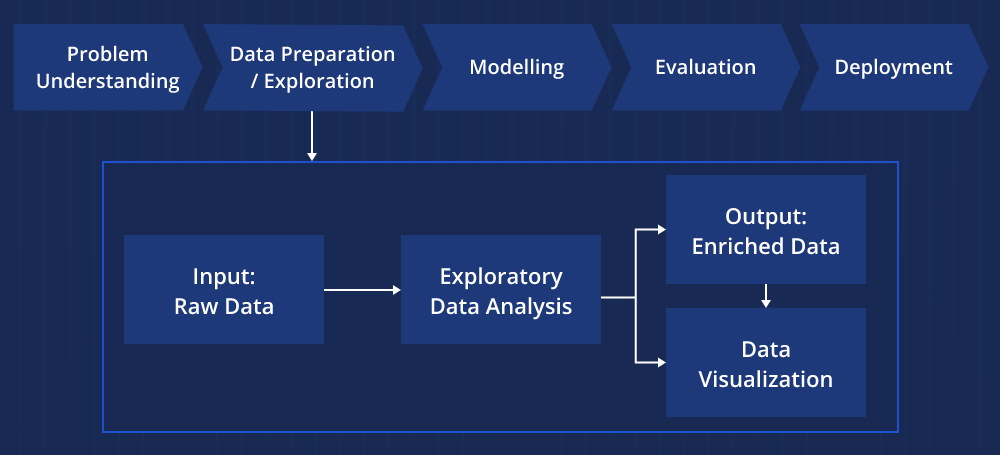

The following code is a custom-built Python framework for automated data cleaning, exploratory data analysis (EDA), and interactive visualization, mainly designed for use in Google Colab. It uses libraries like Pandas, NumPy, SciPy, and Plotly to process datasets and generate interactive charts.

*   The PlottingMethods class handles visualization tasks such as bar charts, pie charts, histograms, heatmaps, Sankey diagrams, and sunburst graphs
*   the DataInspector class manages data upload, automatic datatype correction, missing value handling, duplicate removal, outlier detection, normalization, encoding of categorical variables, and statistical correlation analysis

It also provides advanced plotting functions for numerical, categorical, and mixed-variable relationships, including correlation heatmaps using Pearson correlation and Cramér’s V. Overall, the program acts as a lightweight interactive analytics toolkit that helps users quickly clean, analyze, and visualize datasets without writing repetitive analysis code manually.

In [2]:
import io
import json
import numpy as np
import pandas as pd
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

class PlottingMethods:
    """
    Modular, isolated plotting engine. Generates interactive Plotly figures,
    wraps them into diagnostic metadata transmission schemas, and displays
    them inside cell outputs.
    """
    @staticmethod
    def get_methods_info() -> dict:
        methods = [
            {"method_name": "plot_bar_chart", "type": "Distribution / Categorical Split"},
            {"method_name": "plot_pie_chart", "type": "Compositional Proportions"},
            {"method_name": "plot_histogram", "type": "Continuous Value Density Mapping"},
            {"method_name": "plot_heat_map", "type": "Aggregated Matrix Breakdown"},
            {"method_name": "plot_sankey_diagram", "type": "Hierarchical Data Flow"},
            {"method_name": "plot_simple_sunburst_graph", "type": "Multi-level Radial Proportions"}
        ]
        return {"status": "success", "response": methods}

    @staticmethod
    def display_image(result: dict) -> None:
        if not result or result.get("status") != "success":
            print("X Invalid visualization bundle. Structural extraction failed.")
            return
        display(HTML(result.get("data", "")))

    def _wrap_figure(self, fig: go.Figure) -> dict:
        try:
            html_str = fig.to_html(include_plotlyjs='cdn', full_html=False, config={'responsive': True})
            return {"status": "success", "data": html_str}
        except Exception as e:
            return {"status": "failed", "error": str(e)}

    def plot_bar_chart(self, x: str, y: str = None, color: str = None, barmode: str = 'group', data: pd.DataFrame = None) -> dict:
        if data is None or x not in data.columns:
            return {"status": "failed", "error": f"Target column '{x}' missing."}
        if y is None:
            counts = data[x].value_counts().reset_index()
            counts.columns = [x, 'count']
            counts['percentage'] = (counts['count'] / counts['count'].sum() * 100).round(2)
            counts['label'] = counts.apply(lambda r: f"{r['count']} ({r['percentage']}%)", axis=1)
            fig = px.bar(counts, x=x, y='count', text='label', title=f"Frequency Profile: {x}")
            fig.update_traces(textposition='outside')
        else:
            fig = px.bar(data, x=x, y=y, color=color, barmode=barmode, title=f"Bar Analysis: {x} vs {y}")
        fig.update_layout(template='plotly_white')
        return self._wrap_figure(fig)

    def plot_pie_chart(self, names: str, values: str = None, hole: float = 0.4, title: str = None, data: pd.DataFrame = None) -> dict:
        if data is None or names not in data.columns:
            return {"status": "failed", "error": f"Dimension '{names}' not found."}
        fig = px.pie(data, names=names, values=values, hole=hole, title=title or f"Share: {names}")
        fig.update_layout(template='plotly_white')
        return self._wrap_figure(fig)

    def plot_histogram(self, x: str, bins: list = None, title: str = None, data: pd.DataFrame = None) -> dict:
        if data is None or x not in data.columns:
            return {"status": "failed", "error": f"Column '{x}' non-existent."}
        fig = px.histogram(data, x=x, title=title or f"Density Distribution: {x}")
        if bins is not None:
            fig.update_traces(xbins=dict(start=min(bins), end=max(bins), size=(max(bins)-min(bins))/len(bins)))
        fig.update_layout(template='plotly_white')
        return self._wrap_figure(fig)

    def plot_heat_map(self, values: str, index: str, columns: str, aggregade_method: str = 'mean', title: str = None, data: pd.DataFrame = None) -> dict:
        if data is None: return {"status": "failed", "error": "No dataset specified."}
        pivot_df = data.pivot_table(values=values, index=index, columns=columns, aggfunc=aggregade_method)
        fig = px.imshow(pivot_df, text_auto=True, aspect="auto", color_continuous_scale="RdBu_r", title=title or f"Matrix Heatmap Grid Layout")
        fig.update_layout(template='plotly_white')
        return self._wrap_figure(fig)

    def plot_sankey_diagram(self, source_column: str, target_column: str, values: str, data: pd.DataFrame = None) -> dict:
        if data is None: return {"status": "failed", "error": "Empty reference frame."}
        agg = data.groupby([source_column, target_column])[values].sum().reset_index()
        all_nodes = list(pd.concat([agg[source_column], agg[target_column]]).unique())
        node_map = {node: idx for idx, node in enumerate(all_nodes)}
        fig = go.Figure(data=[go.Sankey(
            node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=all_nodes),
            link=dict(source=agg[source_column].map(node_map), target=agg[target_column].map(node_map), value=agg[values])
        )])
        fig.update_layout(title_text=f"Flow Topology: {source_column} ➔ {target_column}", template="plotly_white")
        return self._wrap_figure(fig)

    def plot_simple_sunburst_graph(self, path: list, values: str, data: pd.DataFrame = None, title: str = None) -> dict:
        if data is None: return {"status": "failed", "error": "Missing frame references."}
        fig = px.sunburst(data, path=path, values=values, title=title or "Hierarchical Sunburst Graph")
        fig.update_layout(template='plotly_white')
        return self._wrap_figure(fig)


class DataInspector:
    """
    Automated analytical processing engine. Manages missing structural allocations,
    cleans garbage tokens, updates variable datatypes, and generates deep exploratory charts.
    """
    def __init__(self):
        self.df = None
        self.numeric_cols = []
        self.categorical_cols = []
        self.garbage_values = ['?', 'n/a', 'NULL', ' ', 'NA', 'NaN', 'null', 'None']
        self._plotter = PlottingMethods()

    def upload_data(self) -> None:
        try:
            from google.colab import files
            uploaded = files.upload()
            if not uploaded:
                print("⚠ File import protocol aborted.")
                return
            file_name = list(uploaded.keys())[0]
            self.df = pd.read_csv(io.BytesIO(uploaded[file_name]), na_values=self.garbage_values)
            print(f"✓ Successfully registered file system node stream: {file_name}")
            self._auto_type_correction()
            self.refresh_column_types()
        except ImportError:
            print("X Can only run interactively inside Google Colab environments.")

    def _auto_type_correction(self) -> None:
        if self.df is None: return
        for col in self.df.columns:
            if self.df[col].dtype == 'object':
                converted = pd.to_numeric(self.df[col], errors='coerce')
                if not converted.isna().all():
                    self.df[col] = converted

    def refresh_column_types(self) -> None:
        if self.df is None: return
        self.numeric_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = self.df.select_dtypes(exclude=[np.number]).columns.tolist()

    def get_summary(self) -> None:
        if self.df is None: return
        print(f"\n====== STRUCTURAL SPACE SUMMARY ======")
        print(f"Rows: {self.df.shape[0]} | Columns: {self.df.shape[1]}")
        print(f"Numerical Features: {self.numeric_cols}")
        print(f"Categorical Nodes: {self.categorical_cols}")
        print(f"======================================\n")
        display(self.df.head(20))

    def column_details(self) -> None:
        if self.df is None: return
        print(self.df.info())

    def get_categorical_summary(self) -> None:
        if self.df is None: return
        for col in self.categorical_cols:
            print(f"\nValue Composition for: '{col}'")
            print(self.df[col].value_counts(dropna=False))

    def show_missing_data(self) -> None:
        if self.df is None: return
        missing_counts = self.df.isna().sum()
        missing_pct = (missing_counts / len(self.df)) * 100
        summary_df = pd.DataFrame({"Missing Nodes": missing_counts, "Percentage Share (%)": missing_pct.round(2)})
        display(summary_df[summary_df["Missing Nodes"] > 0])

    def handle_missing_values(self, strategy: str = 'median', fill_value=None) -> None:
        if self.df is None: return
        strategy = strategy.lower()
        for col in self.df.columns:
            if self.df[col].isna().sum() == 0: continue
            if col in self.numeric_cols:
                if strategy == 'mean': self.df[col] = self.df[col].fillna(self.df[col].mean())
                elif strategy == 'median': self.df[col] = self.df[col].fillna(self.df[col].median())
                elif strategy == 'mode': self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                elif strategy == 'constant' and fill_value is not None: self.df[col] = self.df[col].fillna(fill_value)
            else:
                m_val = self.df[col].mode()
                fill = m_val[0] if not m_val.empty else "Missing"
                self.df[col] = self.df[col].fillna(fill if strategy != 'constant' else str(fill_value))
        print(f"✓ Missing values handled via strategy: '{strategy}'")

    def remove_duplicates(self) -> None:
        if self.df is None: return
        init_len = len(self.df)
        self.df.drop_duplicates(inplace=True)
        print(f"✓ Removed {init_len - len(self.df)} duplicate row matches.")

    def handle_outliers(self, columns: list, find_and_delete: bool = True) -> None:
        if self.df is None: return
        mask = pd.Series(False, index=self.df.index)
        for col in columns:
            if col in self.numeric_cols:
                q1, q3 = self.df[col].quantile(0.25), self.df[col].quantile(0.75)
                iqr = q3 - q1
                low_b, up_b = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                col_outliers = (self.df[col] < low_b) | (self.df[col] > up_b)
                mask = mask | col_outliers
                print(f"🔍 Found {col_outliers.sum()} outliers in column: '{col}'")
        if find_and_delete:
            pre_cnt = len(self.df)
            self.df = self.df[~mask]
            print(f"✓ Pruned {pre_cnt - len(self.df)} outlier rows.")
        else:
            self.df['is_outlier'] = mask.astype(int)
            print("✓ Added tracker column: 'is_outlier'.")
        self.refresh_column_types()

    def delete_rows(self, row_indices_str: str = "") -> None:
        if self.df is None or not row_indices_str: return
        idx_list = [int(i.strip()) for i in row_indices_str.split(',') if i.strip()]
        self.df.drop(index=idx_list, inplace=True, errors='ignore')
        print(f"✓ Pruned row indices: {idx_list}")

    def delete_columns(self, column_names_str: str = "") -> None:
        if self.df is None or not column_names_str: return
        cols = [c.strip() for c in column_names_str.split(',') if c.strip()]
        self.df.drop(columns=cols, inplace=True, errors='ignore')
        print(f"✓ Dropped features: {cols}")
        self.refresh_column_types()

    def extract_normalized_numeric_data(self, method: str = 'standard') -> pd.DataFrame:
        if self.df is None or not self.numeric_cols: return pd.DataFrame()
        df_sub = self.df[self.numeric_cols].copy()
        for col in df_sub.columns:
            if method == 'minmax':
                mn, mx = df_sub[col].min(), df_sub[col].max()
                df_sub[col] = (df_sub[col] - mn) / (mx - mn) if (mx - mn) > 0 else 0
            elif method == 'robust':
                q1, q3 = df_sub[col].quantile(0.25), df_sub[col].quantile(0.75)
                iqr = q3 - q1  # Patched variable sequence declaration
                df_sub[col] = (df_sub[col] - df_sub[col].median()) / iqr if iqr > 0 else 0
            else:
                st = df_sub[col].std()
                df_sub[col] = (df_sub[col] - df_sub[col].mean()) / st if st > 0 else 0
        df_sub.columns = [f"{c}_{method}" for c in df_sub.columns]
        return df_sub

    def extract_normalized_categorical_data(self, method: str = 'onehot') -> pd.DataFrame:
        if self.df is None or not self.categorical_cols: return pd.DataFrame()
        if method == 'onehot':
            return pd.get_dummies(self.df[self.categorical_cols], drop_first=True, dtype=float)
        df_out = pd.DataFrame(index=self.df.index)
        for col in self.categorical_cols:
            cats = self.df[col].astype(str).unique()
            cat_map = {cat: idx for idx, cat in enumerate(cats)}
            df_out[f"{col}_encoded"] = self.df[col].astype(str).map(cat_map).astype(float)
            if method == 'uniform' and len(cats) > 1:
                df_out[f"{col}_encoded"] /= df_out[f"{col}_encoded"].max()
                df_out.rename(columns={f"{col}_encoded": f"{col}_uniform"}, inplace=True)
        return df_out

    def create_normalized_data_df(self) -> pd.DataFrame:
        return pd.concat([self.extract_normalized_numeric_data(method='standard'),
                          self.extract_normalized_categorical_data(method='onehot')], axis=1)

    def plot_numerical(self, column_names: list) -> None:
        if self.df is None: return
        for col in column_names:
            if col not in self.numeric_cols: continue
            fig = make_subplots(rows=3, cols=1, vertical_spacing=0.1,
                                subplot_titles=(f"Violin & Box: {col}", f"Index Scatter Plot: {col}", f"Frequency Histogram: {col}"))
            fig.add_trace(go.Violin(x=self.df[col], box_visible=True, meanline_visible=True, name="Distribution"), row=1, col=1)
            fig.add_trace(go.Scatter(x=self.df.index, y=self.df[col], mode='markers', marker=dict(opacity=0.5)), row=2, col=1)
            fig.add_trace(go.Histogram(x=self.df[col]), row=3, col=1)
            fig.update_layout(height=750, title_text=f"Advanced Univariate Profile — {col}", template="plotly_white", showlegend=False)
            fig.show()

    def plot_categorical(self, column_names: list) -> None:
        if self.df is None: return
        for col in column_names:
            if col in self.df.columns:
                self.display_image(self._plotter.plot_bar_chart(x=col, data=self.df))

    def plot_relationship(self, var1: str, var2: str) -> None:
        if self.df is None or var1 not in self.df.columns or var2 not in self.df.columns: return
        v1_n, v2_n = var1 in self.numeric_cols, var2 in self.numeric_cols
        if v1_n and v2_n:
            fig = px.scatter(self.df, x=var1, y=var2, trendline="ols", title=f"Scatter: {var1} vs {var2}")
        elif (v1_n and not v2_n) or (not v1_n and v2_n):
            num, cat = (var1, var2) if v1_n else (var2, var1)
            fig = px.box(self.df, x=cat, y=num, points="all", title=f"Box Distribution: {cat} vs {num}")
        else:
            grouped = self.df.groupby([var1, var2]).size().reset_index(name='counts')
            fig = px.bar(grouped, x=var1, y='counts', color=var2, barmode='group', title=f"Grouped Frequency: {var1} vs {var2}")
        fig.update_layout(template='plotly_white')
        fig.show()

    def plot_numerical_correlation(self) -> None:
        if self.df is None or not self.numeric_cols: return
        fig = px.imshow(self.df[self.numeric_cols].corr(method='pearson'), text_auto=True, color_continuous_scale="RdBu", zmin=-1, zmax=1, title="Pearson Correlation Heatmap")
        fig.show()

    def plot_categorical_correlation(self) -> None:
        if self.df is None or not self.categorical_cols: return
        df_c = self.df[self.categorical_cols].dropna()
        cols, n = df_c.columns.tolist(), len(df_c.columns)
        mat = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i == j: mat[i, j] = 1.0; continue
                ct = pd.crosstab(df_c[cols[i]], df_c[cols[j]])
                if ct.size == 0 or ct.sum().sum() == 0: continue
                chi2 = stats.chi2_contingency(ct)[0]
                total = ct.sum().sum()
                r, k = ct.shape
                phi2 = max(0, (chi2 / total) - ((k-1)*(r-1))/(total-1))
                r_c = r - ((r-1)**2)/(total-1)
                k_c = k - ((k-1)**2)/(total-1)
                mat[i, j] = np.sqrt(phi2 / min((k_c - 1), (r_c - 1))) if min((k_c - 1), (r_c - 1)) > 0 else 0.0
        fig = px.imshow(mat, x=cols, y=cols, text_auto=True, color_continuous_scale="Blues", zmin=0, zmax=1, title="Cramér's V Heatmap")
        fig.show()

    def plot_all_associations_heatmap(self) -> None:
        if self.df is None: return

        # Drop high-cardinality metadata tags that break group variance calculations
        ignore_cols = ['Name', 'Ticket', 'PassengerId']
        valid_cols = [c for c in self.df.columns if c not in ignore_cols]

        df_clean = self.df[valid_cols].dropna()
        cols = df_clean.columns.tolist()
        n = len(cols)

        matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i == j: matrix[i, j] = 1.0; continue
                c1, c2 = cols[i], cols[j]

                # 1. Numeric vs Numeric (Pearson)
                if c1 in self.numeric_cols and c2 in self.numeric_cols:
                    matrix[i, j] = 0.0 if df_clean[c1].std() == 0 or df_clean[c2].std() == 0 else stats.pearsonr(df_clean[c1], df_clean[c2])[0]

                # 2. Categorical vs Categorical (Bias-Corrected Cramér's V)
                elif c1 in self.categorical_cols and c2 in self.categorical_cols:
                    ct = pd.crosstab(df_clean[c1], df_clean[c2])
                    if ct.size == 0 or ct.sum().sum() == 0: continue

                    chi2 = stats.chi2_contingency(ct)[0]
                    total = ct.sum().sum()
                    phi2 = max(0, (chi2 / total) - ((ct.shape[1]-1)*(ct.shape[0]-1))/(total-1))

                    # Math safety layer logic to block zero division anomalies
                    denom_k = ct.shape[1] - ((ct.shape[1]-1)**2)/(total-1) - 1
                    denom_r = ct.shape[0] - ((ct.shape[0]-1)**2)/(total-1) - 1
                    denominator = min(denom_k, denom_r)

                    if denominator <= 0 or min((ct.shape[1]-1), (ct.shape[0]-1)) <= 0:
                        matrix[i, j] = 0.0
                    else:
                        matrix[i, j] = np.sqrt(phi2 / denominator)

                # 3. Mixed Types (Eta via ANOVA)
                else:
                    num_f, cat_f = (c1, c2) if c1 in self.numeric_cols else (c2, c1)
                    grps = [g['val'].values for name, g in pd.DataFrame({'cat': df_clean[cat_f], 'val': df_clean[num_f]}).groupby('cat') if len(g) > 0]

                    if len(grps) > 1:
                        try:
                            # Intercept low sample warnings safely
                            import warnings
                            with warnings.catch_warnings():
                                warnings.simplefilter("ignore")
                                f_stat = stats.f_oneway(*grps)[0]

                            if f_stat > 0 and not np.isnan(f_stat):
                                ss_b = sum(len(g) * (np.mean(g) - df_clean[num_f].mean())**2 for g in grps)
                                ss_t = sum((df_clean[num_f] - df_clean[num_f].mean())**2)
                                matrix[i, j] = np.sqrt(ss_b / ss_t) if ss_t > 0 else 0.0
                        except Exception:
                            matrix[i, j] = 0.0

        fig = go.Figure(data=go.Heatmap(z=matrix, x=cols, y=cols, colorscale='RdBu', zmin=-1, zmax=1, text=np.round(matrix, 2), texttemplate="%{text}"))
        fig.update_layout(title="Unified Mixed-Variable Feature Association Heatmap (Robust Cleaned)", template='plotly_white')
        fig.show()

    def display_image(self, result: dict) -> None:
        self._plotter.display_image(result)

The following implementation demonstrate the data visualization of the DataInspector framework using a reaal-world data set which was penetrated via the Titanic CSV dataset directly from a GitHub URL into a Pandas DataFrame.

Finally, the code normalizes and encodes the dataset into a machine-learning-ready feature matrix and prints the final processed data shape, confirming that the full preprocessing and visualization pipeline executed successfully.

In [5]:
# Initialize Engine Workspace
inspector = DataInspector()

# Ingest data elements
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
inspector.df = pd.read_csv(url)
inspector.refresh_column_types()

print("--- 1. Summary Information Matrix ---")
inspector.get_summary()

print("\n--- 2. Impute and Clean Missing Blocks ---")
inspector.show_missing_data()
inspector.handle_missing_values(strategy='median')

print("\n--- 3. Boundary Outlier Anomaly Management ---")
inspector.handle_outliers(columns=['Fare', 'Age'], find_and_delete=True)
inspector.remove_duplicates()

print("\n--- 4. Visual Analysis & Mixed Matrix Maps ---")
inspector.plot_numerical(column_names=['Age'])
inspector.plot_relationship('Sex', 'Fare')

# Execution fix verified
inspector.plot_all_associations_heatmap()

print("\n--- 5. Feature Modeling Matrix Output ---")
final_df = inspector.create_normalized_data_df()
print(f"✓ Pipeline flow running successfully. Shape outcome matrix: {final_df.shape}")

--- 1. Summary Information Matrix ---

====== STRUCTURAL SPACE SUMMARY ======
Rows: 891 | Columns: 12
Numerical Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Nodes: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



--- 2. Impute and Clean Missing Blocks ---


,Missing Nodes,Percentage Share (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


✅ Missing values handled via strategy: 'median'

--- 3. Boundary Outlier Anomaly Management ---
🔍 Found 116 outliers in column: 'Fare'
🔍 Found 66 outliers in column: 'Age'
✅ Pruned 170 outlier rows.
✅ Removed 0 duplicate row matches.

--- 4. Visual Analysis & Mixed Matrix Maps ---



--- 5. Feature Modeling Matrix Output ---
Pipeline flow running successfully. Shape outcome matrix: (721, 1403)
